# Capítulo 4: IA para la Detección de Malware *(Versión Simulada)*

## 4.1. Limitaciones del enfoque basado en firmas

Los sistemas antivirus tradicionales dependen de la detección basada en firmas, lo que los hace ineficaces frente a **malware nuevo o polimórfico**. Esta versión utiliza un dataset PE sintético con **800 archivos benignos** y **200 maliciosos** con propiedades estadísticas diferenciadas.

---
## 4.2. Generación de datos simulados de archivos PE

Los archivos **benignos** tienen características típicas de software legítimo:
- Entropía moderada (4.0–6.5), muchas importaciones, entry points altos.

Los archivos **maliciosos** tienen características de malware empaquetado/ofuscado:
- Alta entropía (6.5–8.0), pocas importaciones, entry points bajos o inusuales.

In [1]:
import numpy as np
import pandas as pd
import os

np.random.seed(42)
os.makedirs('data', exist_ok=True)

n_benign, n_malicious = 800, 200

benign = pd.DataFrame({
    'entry_point':        np.random.randint(4096, 65536, n_benign),
    'image_base':         np.full(n_benign, 4194304),
    'size_of_image':      np.random.randint(50000, 500000, n_benign),
    'size_code_section':  np.random.randint(10000, 200000, n_benign),
    'dll_flag':           np.random.choice([0x8160, 0x8140, 0x8120], n_benign),
    'num_sections':       np.random.choice([3, 4, 5, 6], n_benign, p=[0.1, 0.4, 0.35, 0.15]),
    'entropia_max':       np.random.uniform(4.0, 6.5, n_benign).round(4),
    'entropia_media':     np.random.uniform(3.5, 5.8, n_benign).round(4),
    'num_importaciones':  np.random.randint(50, 400, n_benign),
    'num_dlls_importadas':np.random.randint(5, 25, n_benign),
    'num_exportaciones':  np.random.randint(0, 10, n_benign),
    'file_size':          np.random.randint(50000, 2000000, n_benign),
    'label':              0
})

malicious = pd.DataFrame({
    'entry_point':        np.random.randint(0, 4096, n_malicious),
    'image_base':         np.random.choice([4194304, 268435456, 65536], n_malicious),
    'size_of_image':      np.random.randint(5000, 100000, n_malicious),
    'size_code_section':  np.random.randint(500, 15000, n_malicious),
    'dll_flag':           np.random.choice([0x0000, 0x0040, 0x8160], n_malicious, p=[0.5, 0.3, 0.2]),
    'num_sections':       np.random.choice([1, 2, 3, 8, 10], n_malicious, p=[0.2, 0.3, 0.2, 0.2, 0.1]),
    'entropia_max':       np.random.uniform(6.5, 8.0, n_malicious).round(4),
    'entropia_media':     np.random.uniform(5.5, 7.8, n_malicious).round(4),
    'num_importaciones':  np.random.randint(2, 30, n_malicious),
    'num_dlls_importadas':np.random.randint(1, 5, n_malicious),
    'num_exportaciones':  np.random.randint(0, 2, n_malicious),
    'file_size':          np.random.randint(5000, 80000, n_malicious),
    'label':              1
})

df_pe = pd.concat([benign, malicious], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
df_pe.to_csv('data/file_features.csv', index=False)

print(f"[OK] data/file_features.csv generado")
print(f"     Total: {len(df_pe)} | Benign: {n_benign} | Malicious: {n_malicious}")
df_pe.head()

[OK] data/file_features.csv generado
     Total: 1000 | Benign: 800 | Malicious: 200


,entry_point,image_base,size_of_image,size_code_section,dll_flag,num_sections,entropia_max,entropia_media,num_importaciones,num_dlls_importadas,num_exportaciones,file_size,label
0,6464,4194304,312379,177516,33088,6,6.1198,3.7907,162,8,2,266383,0
1,48521,4194304,146731,193305,33088,5,4.8688,3.9490,367,11,4,331383,0
2,39831,4194304,112823,92189,33088,5,5.6733,5.7718,386,9,6,918408,0
3,44254,4194304,349363,178484,33088,4,5.6903,4.7183,203,10,8,915718,0
4,38082,4194304,385623,163962,33088,6,5.3835,3.7015,144,23,5,201733,0


---
## 4.3. Exploración del dataset PE

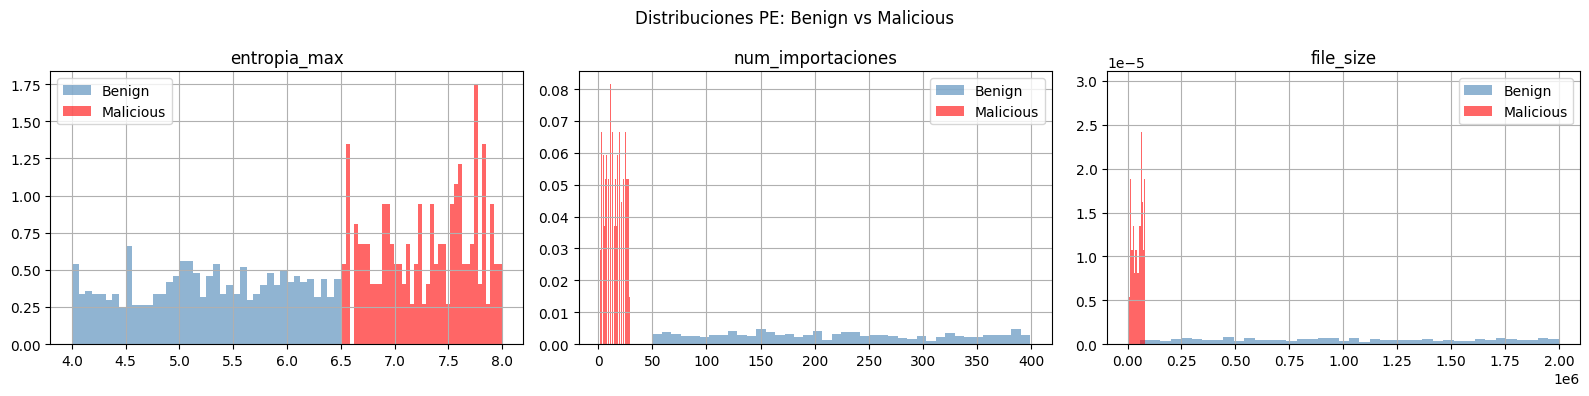

In [2]:
import matplotlib.pyplot as plt

df = pd.read_csv('data/file_features.csv')

# Comparar distribuciones clave entre benigno y malicioso
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['entropia_max', 'num_importaciones', 'file_size']):
    df[df['label']==0][col].hist(bins=40, alpha=0.6, ax=ax, color='steelblue', label='Benign', density=True)
    df[df['label']==1][col].hist(bins=40, alpha=0.6, ax=ax, color='red', label='Malicious', density=True)
    ax.set_title(col)
    ax.legend()
plt.suptitle('Distribuciones PE: Benign vs Malicious')
plt.tight_layout()
plt.savefig('data/pe_distribution.png', dpi=150)
plt.show()

---
## 4.4. Modelo de clasificación de malware

### 4.4.1. Árbol de decisión

=== Reporte de clasificación ===
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00       160
   Malicious       1.00      1.00      1.00        40

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

F1 CV (5-fold): 1.0000 ± 0.0000


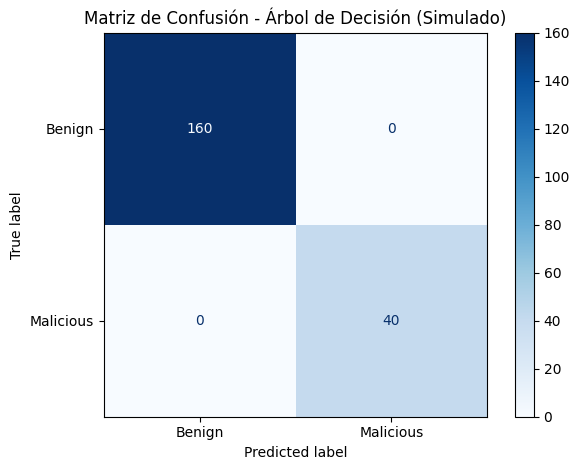

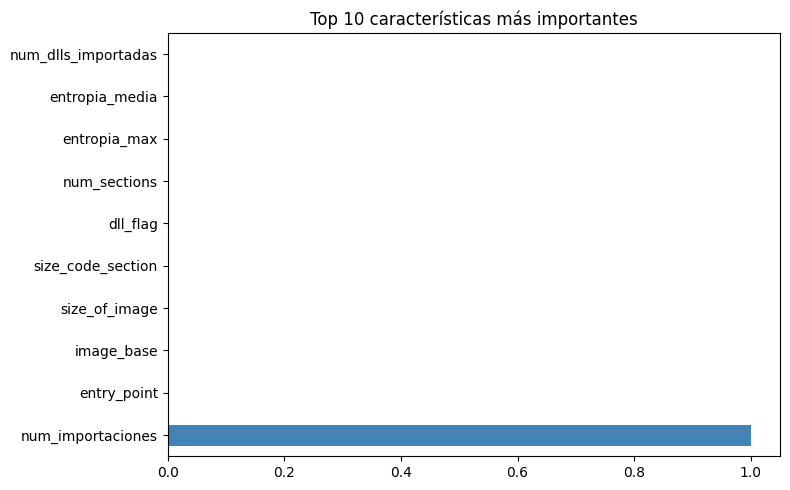

In [3]:
# Listing 4.4: Clasificador de malware con árbol de decisión

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv('data/file_features.csv').dropna()
X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = DecisionTreeClassifier(max_depth=10, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("=== Reporte de clasificación ===")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malicious']))

cv_scores = cross_val_score(clf, X, y, cv=5, scoring='f1')
print(f"F1 CV (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Malicious'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Árbol de Decisión (Simulado)')
plt.tight_layout()
plt.savefig('data/confusion_matrix_dt.png', dpi=150)
plt.show()

importancias = pd.Series(clf.feature_importances_, index=X.columns).nlargest(10)
importancias.plot(kind='barh', color='steelblue', figsize=(8, 5))
plt.title('Top 10 características más importantes')
plt.tight_layout()
plt.savefig('data/feature_importance.png', dpi=150)
plt.show()

### 4.4.2. Random Forest con manejo de clases desbalanceadas

Antes SMOTE:   {0: 640, 1: 160}
Después SMOTE: {0: 640, 1: 640}



=== Reporte de clasificación (RF + SMOTE) ===
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00       160
   Malicious       1.00      1.00      1.00        40

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



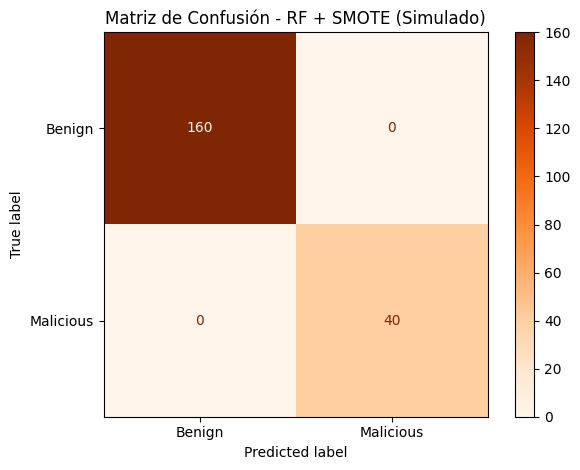

In [4]:
# Listing 4.5: Random Forest con SMOTE

from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

df = pd.read_csv('data/file_features.csv').dropna()
X, y = df.drop('label', axis=1), df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"Antes SMOTE:   {y_train.value_counts().to_dict()}")
print(f"Después SMOTE: {y_train_res.value_counts().to_dict()}")

rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)
print("\n=== Reporte de clasificación (RF + SMOTE) ===")
print(classification_report(y_test, y_pred_rf, target_names=['Benign', 'Malicious']))

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['Benign', 'Malicious']).plot(cmap='Oranges')
plt.title('Matriz de Confusión - RF + SMOTE (Simulado)')
plt.tight_layout()
plt.savefig('data/confusion_matrix_rf.png', dpi=150)
plt.show()

---
## 4.5. Guardado de artefactos

In [5]:
import joblib

os.makedirs('models', exist_ok=True)
joblib.dump(clf, 'models/decision_tree_malware.pkl')
joblib.dump(rf, 'models/random_forest_malware.pkl')
joblib.dump(list(X.columns), 'models/malware_feature_names.pkl')

print("[OK] models/decision_tree_malware.pkl")
print("[OK] models/random_forest_malware.pkl")
print("[OK] models/malware_feature_names.pkl")

[OK] models/decision_tree_malware.pkl
[OK] models/random_forest_malware.pkl
[OK] models/malware_feature_names.pkl
